# Projet Data Viz

By: Aliou Badji, Rodrigue Mellot-Cavelier and Jesse van der Ende

## Importing packages and data exploration

In [1]:
# Packages
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import kagglehub

# Bokeh functions
from bokeh.plotting import figure
from bokeh.layouts import column, row, layout
from bokeh.io import output_notebook, show
from bokeh.models import (ColumnDataSource, DateRangeSlider, Range1d, Select, HoverTool, 
Span, BoxAnnotation, Legend, DatetimeTickFormatter, NumeralTickFormatter, Title, Div)



/home/ensai/Documents/Data Visualization/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2023/2023-04-04/soccer21-22.csv"
soccer = pd.read_csv(url)

soccer.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,13/08/2021,Brentford,Arsenal,2,0,H,1,0,H,M Oliver,...,3,4,12,8,2,5,0,0,0,0
1,14/08/2021,Man United,Leeds,5,1,H,1,0,H,P Tierney,...,8,3,11,9,5,4,1,2,0,0
2,14/08/2021,Burnley,Brighton,1,2,A,1,0,H,D Coote,...,3,8,10,7,7,6,2,1,0,0
3,14/08/2021,Chelsea,Crystal Palace,3,0,H,2,0,H,J Moss,...,6,1,15,11,5,2,0,0,0,0
4,14/08/2021,Everton,Southampton,3,1,H,0,1,A,A Madley,...,6,3,13,15,6,8,2,0,0,0


In [3]:
# Data summary
print(soccer.describe())
print(soccer.isnull().sum())

             FTHG        FTAG        HTHG        HTAG          HS          AS  \
count  380.000000  380.000000  380.000000  380.000000  380.000000  380.000000   
mean     1.513158    1.305263    0.681579    0.589474   13.847368   11.736842   
std      1.326545    1.258836    0.832187    0.808853    5.661784    5.348460   
min      0.000000    0.000000    0.000000    0.000000    3.000000    1.000000   
25%      1.000000    0.000000    0.000000    0.000000    9.000000    8.000000   
50%      1.000000    1.000000    0.000000    0.000000   13.500000   11.000000   
75%      2.000000    2.000000    1.000000    1.000000   17.000000   15.000000   
max      7.000000    6.000000    4.000000    4.000000   31.000000   31.000000   

              HST         AST          HF          AF          HC          AC  \
count  380.000000  380.000000  380.000000  380.000000  380.000000  380.000000   
mean     4.678947    4.142105   10.055263   10.157895    5.602632    4.821053   
std      2.600402    2.5899

## Plot 1: Radar Chart

In [4]:
# Aggregate sums
df = pd.DataFrame({
    'team': ['Home', 'Away'],
    'Shots on Target': [soccer['HST'].sum(), soccer['AST'].sum()],
    'Shots': [soccer['HS'].sum(), soccer['AS'].sum()],
    'Corners': [soccer['HC'].sum(), soccer['AC'].sum()],
    'Fouls': [soccer['HF'].sum(), soccer['AF'].sum()],
    'Goals': [soccer['FTHG'].sum(), soccer['FTAG'].sum()]
})

df.head()

,team,Shots on Target,Shots,Corners,Fouls,Goals
0,Home,1778,5262,2129,3821,575
1,Away,1574,4460,1832,3860,496


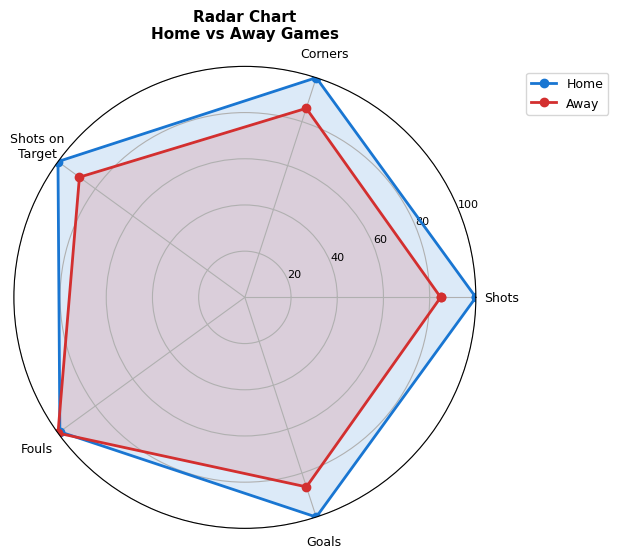

In [5]:
# Radar chart with mathplotlib
stats = ['Shots', 'Corners', 'Shots on Target','Fouls','Goals']
teams = df['team'].tolist()

# Get the radar data
radar_data = []
for _, df_row in df.iterrows():
    values = [
        (df_row['Shots'] / df['Shots'].max()) * 100,
        (df_row['Corners'] / df['Corners'].max()) * 100,
        (df_row['Shots on Target'] / df['Shots on Target'].max()) * 100,
        (df_row['Fouls'] / df['Fouls'].max()) * 100,
        (df_row['Goals'] / df['Goals'].max()) * 100
    ]
    radar_data.append(values)

num_vars = len(stats)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
radar_data = [vals + [vals[0]] for vals in radar_data]
angles += angles[:1]

colors_radar = ['#1976D2', '#D32F2F']

# Create the figure
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(1,1,1, projection='polar')

for i, (team, values) in enumerate(zip(teams, radar_data)):
    ax.plot(angles, values, 'o-', linewidth=2, label=team, color=colors_radar[i])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[i])

# Formatting
labels = ['Shots', 'Corners', 'Shots on\nTarget','Fouls','Goals']
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=9)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20','40','60','80','100'], size=8)
ax.set_title('Radar Chart\nHome vs Away Games', fontsize=11, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.0), fontsize=9)
ax.grid(True)
ax.tick_params(axis='x', pad=8)

## Prepare data set to have Points away vs Points Home

In [6]:
# Points real
soccer["HomePoints"] = soccer["FTR"].map({"H":3,"D":1,"A":0})
soccer["AwayPoints"] = soccer["FTR"].map({"A":3,"D":1,"H":0})
home = soccer.groupby("HomeTeam")["HomePoints"].sum().reset_index()
away = soccer.groupby("AwayTeam")["AwayPoints"].sum().reset_index()
points = pd.merge(home, away, left_on="HomeTeam", right_on="AwayTeam")
points["Equipe"] = points["HomeTeam"]
points["Total"] = points["HomePoints"] + points["AwayPoints"]

# Points alternative
soccer["HomePoints_alt"] = soccer["FTR"].map({"H":0,"D":0,"A":0})
soccer["AwayPoints_alt"] = soccer["FTR"].map({"A":3,"D":1,"H":0})
home_alt = soccer.groupby("HomeTeam")["HomePoints_alt"].sum().reset_index()
away_alt = soccer.groupby("AwayTeam")["AwayPoints_alt"].sum().reset_index()
points_alt = pd.merge(home_alt, away_alt, left_on="HomeTeam", right_on="AwayTeam")
points_alt["Equipe"] = points_alt["HomeTeam"]
points_alt["Total_alt"] = points_alt["HomePoints_alt"] + points_alt["AwayPoints_alt"]

# Final fusion
table = pd.merge(points[["Equipe","Total"]], points_alt[["Equipe","Total_alt"]], on="Equipe")

# Rankings
table["Rank"] = table["Total"].rank(method="min", ascending=False).astype(int)
table["Rank_alt"] = table["Total_alt"].rank(method="min", ascending=False).astype(int)

# Sort by actual ranking
table = table.sort_values("Rank").reset_index(drop=True)

table.head()
points.head()

,HomeTeam,HomePoints,AwayTeam,AwayPoints,Equipe,Total
0,Arsenal,41,Arsenal,28,Arsenal,69
1,Aston Villa,23,Aston Villa,22,Aston Villa,45
2,Brentford,24,Brentford,22,Brentford,46
3,Brighton,22,Brighton,29,Brighton,51
4,Burnley,21,Burnley,14,Burnley,35


## Plot 2: Plot chart

In [7]:
# Title Div
title = Div(
    text="""
    <h1 style="text-align: center; color: #2c3e50;">
        📊 Home vs Away Points Difference - Premier League 21-22
    </h1>
    """,
    width=800,
    height=80,
)

points["PercentageDifference"] = (points["HomePoints"] - points["AwayPoints"]) / (points["HomePoints"] + points["AwayPoints"])

# Determine colors
points["colors"] = np.where(points["PercentageDifference"] >= 0, "green", "red")

# ColumnDataSource for Bokeh
source = ColumnDataSource(data=dict(
    Equipe=points["Equipe"],
    PercentageDifference=points["PercentageDifference"],
    colors=points["colors"]
))

# Create Figure
p = figure(
    x_range=points["Equipe"].tolist(),
    width=800,
    height=400,
    title="Percentage Difference in Home vs Away Points – Premier League 2021/2022",
    toolbar_location="above",
    tools="pan,wheel_zoom,box_zoom,reset,save,hover"
)

# Add bars
p.vbar(
    x="Equipe",
    top="PercentageDifference",
    width=0.8,
    color="colors",
    source=source
)

# Add horizontal lines at 0 and median
mean_val = points["PercentageDifference"].median()
p.line(x=points["Equipe"], y=[0]*len(points), line_color="black", line_width=1)
p.line(x=points["Equipe"], y=[mean_val]*len(points), line_color="orange", line_width=1)

# Axis labels
p.xaxis.major_label_orientation = np.pi/2
p.yaxis.axis_label = "Home Points % - Away Points %"
p.xaxis.axis_label = "Teams"


# Info Panel
info = Div(
    text="""
    <div style="background-color: #ecf0f1; padding: 20px; border-radius: 10px;">
        <h3>🎯 Slide Info:</h3>
        <ul>
            <li>Green bars: More points won at home</li>
            <li>Red bars: More points won away</li>
            <li>Orange line: Median difference</li>
            <li>Interactive: Zoom, pan, hover over bars</li>
        </ul>
    </div>
    """,
    width=400,
    height=250
)

output_notebook()
show(layout([[title], [p, info]]))


Loading BokehJS ...

## Plot 3: Arrow Chart

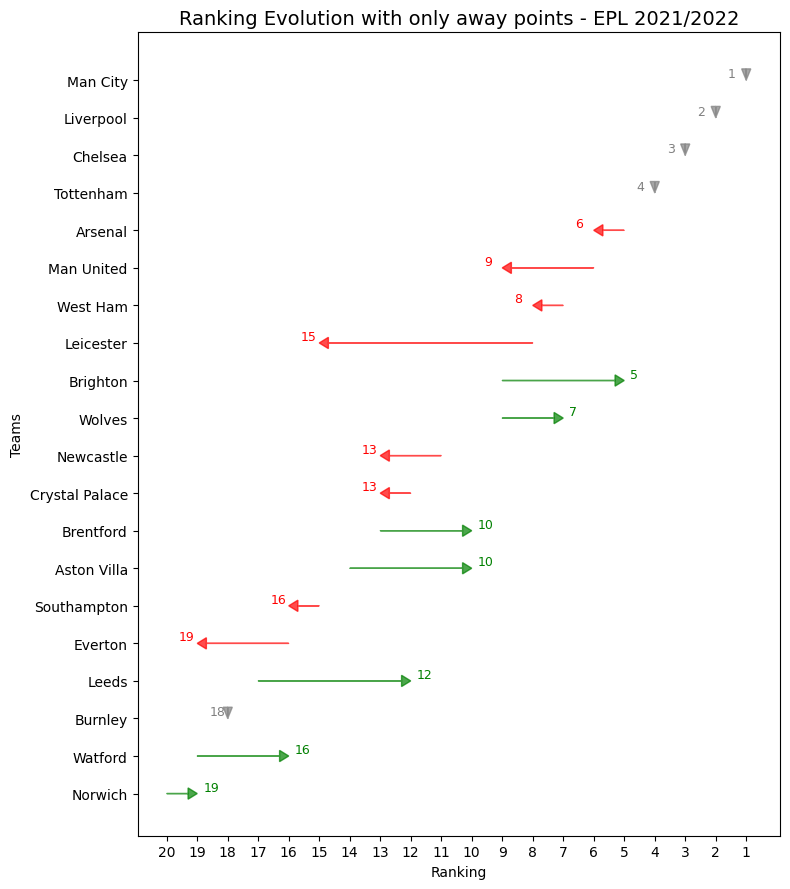

In [8]:

# Create a figure with matplotlib
table["y_pos"] = np.arange(len(table))
fig, ax = plt.subplots(figsize=(8,9))

for _, table_row in table.iterrows():
    # Color according to change in ranking
    if table_row["Rank_alt"] < table_row["Rank"]:
        color = "green"
        adjust_position = -0.2
    elif table_row["Rank_alt"] > table_row["Rank"]:
        color = "red"
        adjust_position = +0.6
    else:
        color = "gray"
        adjust_position = +0.6
    
    # Arrow
    ax.arrow(table_row["Rank"], table_row["y_pos"], 
            table_row["Rank_alt"] - table_row["Rank"], 0,
            head_width=0.3, head_length=0.3,
            length_includes_head=True, color=color, alpha=0.7)
    
    # Text
    ax.text(table_row["Rank_alt"] + adjust_position, table_row["y_pos"], str(table_row["Rank_alt"]),
            va="bottom", fontsize=9, color=color)

ax.set_yticks(table["y_pos"])
ax.set_yticklabels(table["Equipe"])

max_rank = table[["Rank","Rank_alt"]].max().max()
ax.set_xticks(np.arange(max_rank, 0, -1))
ax.invert_xaxis()
ax.invert_yaxis()

ax.set_title("Ranking Evolution with only away points - EPL 2021/2022", fontsize=14)
ax.set_xlabel("Ranking")
ax.set_ylabel("Teams")

plt.tight_layout()
plt.show()

## Plot 4: evolution over time

In [9]:
# Color controls
HOME_LINE_COLOR = "#E74C3C"   # red
AWAY_LINE_COLOR = "#0072B2"   # blue

# Darker Covid shading
PHASE_COLORS = {
    "hard":     {"fill_color": "#2B2B2B", "fill_alpha": 0.30},
    "closed":   {"fill_color": "#555555", "fill_alpha": 0.26},
    "limited":  {"fill_color": "#888888", "fill_alpha": 0.22},
    "capacity": {"fill_color": "#BDBDBD", "fill_alpha": 0.18},
}

# Covid lines
COVID_LINE_COLOR = "black"
COVID_START_LINE_DASH  = "dashed"
COVID_END_LINE_DASH = "dotted"
COVID_LINE_WIDTH = 2

# 1) Load & prepare data
path = kagglehub.dataset_download("prateekchauhands/football-data-top-5-european-leagues")

df_dtypes = {
    'Season':'string','Div':'string','Date':'string','Time':'string',
    'HomeTeam':'string','AwayTeam':'string','FTR':'string','HTR':'string','Referee':'string'
}
df = pd.read_csv(f"{path}/past-data.csv", dtype=df_dtypes)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, format="mixed", errors="coerce")

TOP5 = ["Premier League","Bundesliga","Ligue 1","Serie A","LaLiga"]
START_DATE = pd.Timestamp("2003-08-01")

df = df[df["Div"].isin(TOP5) & (df["Date"] >= START_DATE)].copy()

# Points per match
ftr = df["FTR"]
df["HomePoints"] = np.where(ftr.eq("H"), 3, np.where(ftr.eq("D"), 1, np.where(ftr.eq("A"), 0, np.nan)))
df["AwayPoints"] = np.where(ftr.eq("A"), 3, np.where(ftr.eq("D"), 1, np.where(ftr.eq("H"), 0, np.nan)))
df = df.dropna(subset=["Date","HomePoints","AwayPoints"]).sort_values(["Div","Date"])

# 2) 365-day centered rolling per league
def rolling_365(g: pd.DataFrame) -> pd.DataFrame:
    r = g[["Date","HomePoints","AwayPoints"]].rolling("365D", on="Date", min_periods=1, center=True).mean()
    return pd.DataFrame({"Date": g["Date"].values, "home_roll": r["HomePoints"].values, "away_roll": r["AwayPoints"].values})

rolled = df.groupby("Div", group_keys=False, as_index=False).apply(lambda g: rolling_365(g).assign(Div=g.name), include_groups=False)

# 3) Figure
initial_div = "Premier League"

def select_division(div: str) -> pd.DataFrame:
    return rolled[rolled["Div"] == div].copy()

initial_div_df = select_division(initial_div)

# Date bounds
date_min, date_max = initial_div_df["Date"].min(), initial_div_df["Date"].max()

# Figure
source = ColumnDataSource(initial_div_df)
p = figure(
    title="Home vs Away points per game, Europe’s Top 5 Leagues",
    x_axis_type="datetime",
    x_range=Range1d(start=date_min, end=date_max),
    width=1600, height=700,
    tools="pan,wheel_zoom,box_zoom,reset,save",
    x_axis_label="Date", y_axis_label="Average points per game"
)

# Data lines
home_r = p.line("Date","home_roll", source=source, line_width=3, alpha=0.95, color=HOME_LINE_COLOR)
away_r = p.line("Date","away_roll", source=source, line_width=3, alpha=0.95, color=AWAY_LINE_COLOR)

# Subtitle
subtitle = Title(text=f"{initial_div}: 365-day centered rolling average of points", text_font_size="10pt", text_font_style="italic")
p.add_layout(subtitle, "above")

# 4) Covid phases
PHASES = {
    "Premier League": [
        ("hard",     "13-03-2020", "17-06-2020"),
        ("closed",   "17-06-2020", "02-12-2020"),
        ("limited",  "02-12-2020", "17-05-2021"),
        ("capacity", "17-05-2021", "19-07-2021"),
    ],
    "LaLiga": [
        ("hard",     "12-03-2020", "11-06-2020"),
        ("closed",   "11-06-2020", "16-05-2021"),
        ("limited",  "16-05-2021", "01-08-2021"),
        ("capacity", "01-08-2021", "01-10-2021"),
    ],
    "Bundesliga": [
        ("hard",     "13-03-2020", "16-05-2020"),
        ("closed",   "16-05-2020", "15-09-2020"),
        ("limited",  "15-09-2020", "02-02-2022"),
        ("capacity", "02-02-2022", "09-04-2022"),
    ],
    "Serie A": [
        ("hard",     "09-03-2020", "20-06-2020"),
        ("closed",   "20-06-2020", "19-09-2020"),
        ("limited",  "19-09-2020", "21-07-2021"),
        ("capacity", "21-07-2021", "01-04-2022"),
    ],
    "Ligue 1": [
        ("hard",     "13-03-2020", "11-07-2020"),
        ("limited",  "11-07-2020", "23-07-2021"),
        ("capacity", "23-07-2021", "02-02-2022"),
    ],
}

# Build shaded boxes and start/end lines once; initially hidden (toggled per league)
for league, spans in PHASES.items():
    # Shaded areas
    for phase_key, left_s, right_s in spans:
        left_dt  = pd.to_datetime(left_s,  dayfirst=True)
        right_dt = pd.to_datetime(right_s, dayfirst=True)
        
        style = PHASE_COLORS.get(phase_key, {"fill_color": "#CCCCCC", "fill_alpha": 0.20})
        box = BoxAnnotation(left=left_dt, right=right_dt, line_alpha=0.0, level="underlay",
                            name="phase_box", visible=False, tags=[league, phase_key], **style)
        p.add_layout(box)

    # Covid start line
    start_dt = min(pd.to_datetime(ls, dayfirst=True) for _, ls, _ in spans)
    p.add_layout(Span(location=start_dt, dimension="height", line_color=COVID_LINE_COLOR, line_dash=COVID_START_LINE_DASH , 
                            line_width=COVID_LINE_WIDTH, name="covid_start_line", visible=False, tags=[league]))
    # Covid end line
    end_dt = max(pd.to_datetime(rs, dayfirst=True) for _, _, rs in spans)
    p.add_layout(Span(location=end_dt, dimension="height", line_color=COVID_LINE_COLOR, line_dash=COVID_END_LINE_DASH, 
                    line_width=COVID_LINE_WIDTH, name="covid_end_line", visible=False, tags=[league]))

def update_covid_shading(value):
    for box in p.select(name="phase_box"):
        box.visible = (value in getattr(box, "tags"))
    for line in p.select(name="covid_start_line"):
        line.visible = (value in getattr(line, "tags"))
    for line in p.select(name="covid_end_line"):
        line.visible = (value in getattr(line, "tags"))

# Show initial league’s shading + lines
update_covid_shading(initial_div)

# 5) Hover — clear labels
hover = HoverTool(
    tooltips=[
        ("League", "@Div"),
        ("Date", "@Date{%F}"),
        ("Points in home games", "@home_roll{0.00}"),
        ("Points in away games", "@away_roll{0.00}")
    ],
    formatters={"@Date": "datetime"}
)
p.add_tools(hover)

# 6) League select
select = Select(title="Competition", value=initial_div, options=TOP5)

def update_div(attr, old, new):
    division_df = select_division(select.value)
    source.data = dict(division_df)

    # Update the subtitle
    subtitle.text = f"{select.value}: 365-day centered rolling average of points"

    # Update the covid data for this league
    update_covid_shading(select.value)

select.on_change("value", update_div)

# 7) Date slider
date_slider = DateRangeSlider(
    title="Display window",
    start=date_min, end=date_max, value=(date_min, date_max),
    step=1, format="%Y-%m-%d"
)
def update_slider(attr, old, new):
    p.x_range.start, p.x_range.end = date_slider.value_as_datetime
date_slider.on_change("value", update_slider)

# 8) Legend
legend_items = [("Points in home games", [home_r]), ("Points in away games", [away_r])]

# COVID start marker
dummy_start = p.segment(x0=[np.nan], y0=[np.nan], x1=[np.nan], y1=[np.nan], line_color=COVID_LINE_COLOR, line_dash=COVID_START_LINE_DASH, line_width=4)
legend_items += [("Start of COVID restrictions", [dummy_start])]

# Dummies for the label
dummy_hard     = p.square(x=[np.nan], y=[np.nan], size=20, line_color=None, **PHASE_COLORS["hard"])
dummy_closed   = p.square(x=[np.nan], y=[np.nan], size=20, line_color=None, **PHASE_COLORS["closed"])
dummy_limited  = p.square(x=[np.nan], y=[np.nan], size=20, line_color=None, **PHASE_COLORS["limited"])
dummy_capacity = p.square(x=[np.nan], y=[np.nan], size=20, line_color=None, **PHASE_COLORS["capacity"])
legend_items += [
    ("Matches suspended (lockdown)", [dummy_hard]),
    ("Closed-door matches", [dummy_closed]),
    ("Limited fans (≤25% capacity)", [dummy_limited]),
    ("Capacity increased (>25% capacity)", [dummy_capacity])
]

# COVID end marker
dummy_end   = p.segment(x0=[np.nan], y0=[np.nan], x1=[np.nan], y1=[np.nan], line_color=COVID_LINE_COLOR, line_dash=COVID_END_LINE_DASH, line_width=4)
legend_items += [("COVID restrictions fully lifted", [dummy_end])]

# Construct legend
legend = Legend(items=legend_items, title="Legend", orientation="vertical")

# Legend options
legend.click_policy = "mute"
legend.title_text_font_size = "12pt"
legend.title_text_font_style = "bold"
legend.label_text_font_size = "10pt"
legend.glyph_width  = 30
legend.glyph_height = 22
legend.spacing = 6
legend.padding = 8
legend.margin = 8
legend.label_standoff = 8
p.add_layout(legend, 'right')

# 9) Plot formatting
p.title.text_font_size = "15pt"
p.title.text_font_style = "bold"
p.title.align = "left"

p.xaxis.axis_label_text_font_size = "11pt"
p.yaxis.axis_label_text_font_size = "11pt"
p.axis.major_label_text_font_size = "10pt"
p.axis.axis_label_text_font_style = "normal"

p.xaxis.formatter = DatetimeTickFormatter(days="%d %b %Y", months="%b %Y", years="%Y")
p.xaxis.major_label_orientation = 0.5
p.yaxis.formatter = NumeralTickFormatter(format="0.00")
p.y_range.start = 0
p.y_range.end = 3.0

p.background_fill_color = "#ffffff"
p.border_fill_color = "#ffffff"
p.outline_line_color = "#d9d9d9"
p.outline_line_alpha = 0.6
p.grid.grid_line_color = "#b0b0b0"
p.grid.grid_line_alpha = 0.6
p.grid.grid_line_dash = "dotted"
p.xgrid.minor_grid_line_color = None
p.ygrid.minor_grid_line_color = None

# Layout
output_notebook()
show(column(row(select, date_slider), p))


Loading BokehJS ...

You are generating standalone HTML/JS output, but trying to use real Python
callbacks (i.e. with on_change or on_event). This combination cannot work.

Only JavaScript callbacks may be used with standalone output. For more
information on JavaScript callbacks with Bokeh, see:

    https://docs.bokeh.org/en/latest/docs/user_guide/interaction/js_callbacks.html

Alternatively, to use real Python callbacks, a Bokeh server application may
be used. For more information on building and running Bokeh applications, see:

    https://docs.bokeh.org/en/latest/docs/user_guide/server.html

